In [20]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load merged data
df = pd.read_parquet('../data/merged_crime_data.parquet')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

COLORS = {'Toronto': '#2196F3', 'Vancouver': '#FF5722'}

print(("Data loaded successfully. Here's a preview:"), df.shape)
print(df.dtypes)

Data loaded successfully. Here's a preview: (696694, 10)
city             category
year                int64
month            category
hour                int64
crime_type       category
neighbourhood         str
premise_type          str
latitude          float64
longitude         float64
crime_group      category
dtype: object


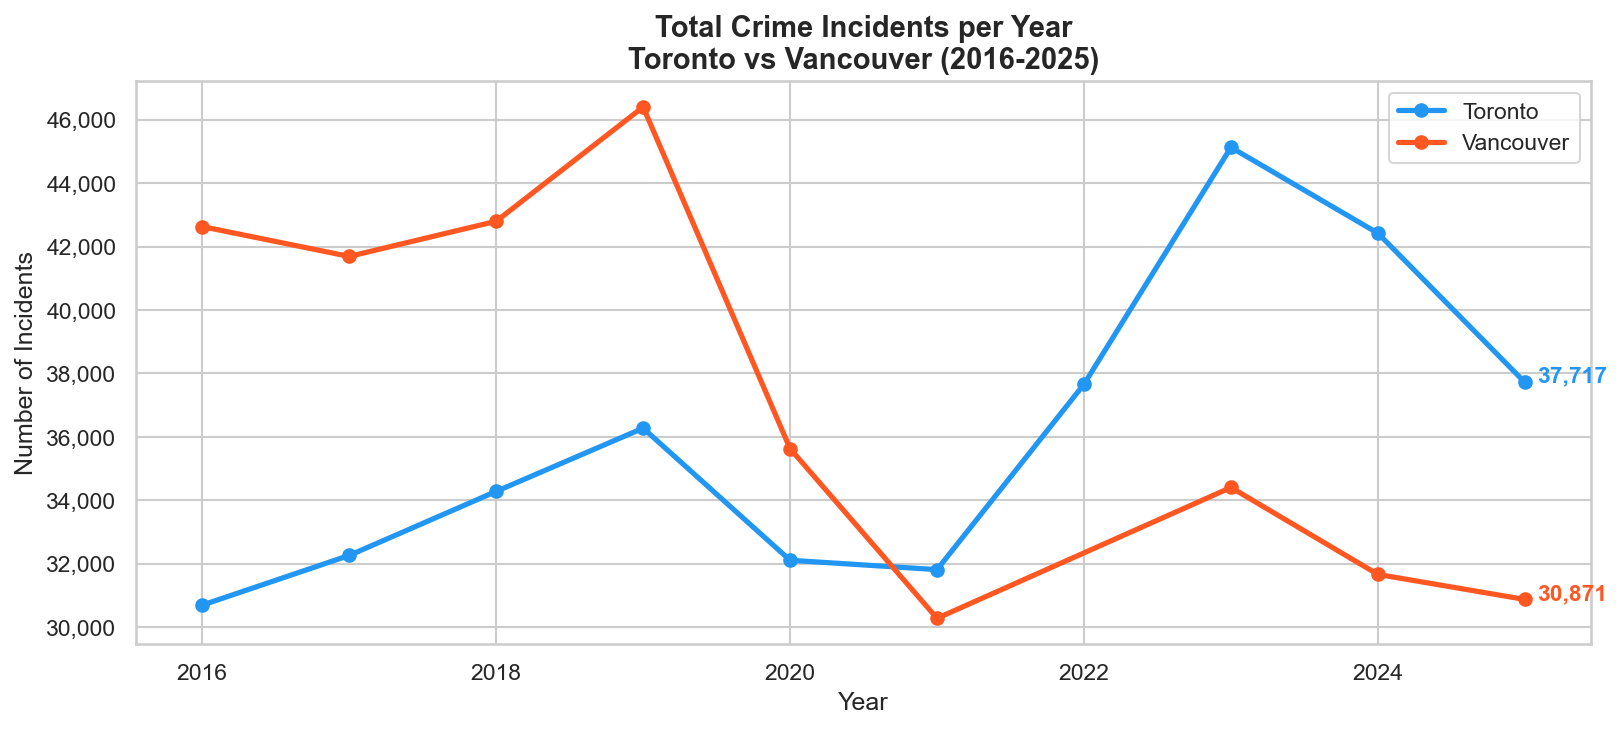

Chart 1 saved as 'total_crimes_over_time.png'


In [21]:
# Chart 1: Total Crimes Over Time
yearly = (
    df.groupby(['city', 'year'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(11, 5))

for city, grp in yearly.groupby('city'):
    ax.plot(grp['year'], grp['count'], marker='o', 
            label=city, color=COLORS[city], linewidth=2.5)
    
    # Label the last point
    ax.annotate(f"{grp['count'].iloc[-1]:,}",
                (grp['year'].iloc[-1], grp['count'].iloc[-1]),
                textcoords="offset points", xytext=(6, 0),
                fontweight='bold', color=COLORS[city])

ax.set_title("Total Crime Incidents per Year\nToronto vs Vancouver (2016-2025)",
             fontsize = 14, fontweight = 'bold')

ax.set_xlabel("Year")
ax.set_ylabel("Number of Incidents")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig("../output/figures/total_crimes_over_time.png", dpi =150, bbox_inches='tight')
plt.show()
print("Chart 1 saved as 'total_crimes_over_time.png'")

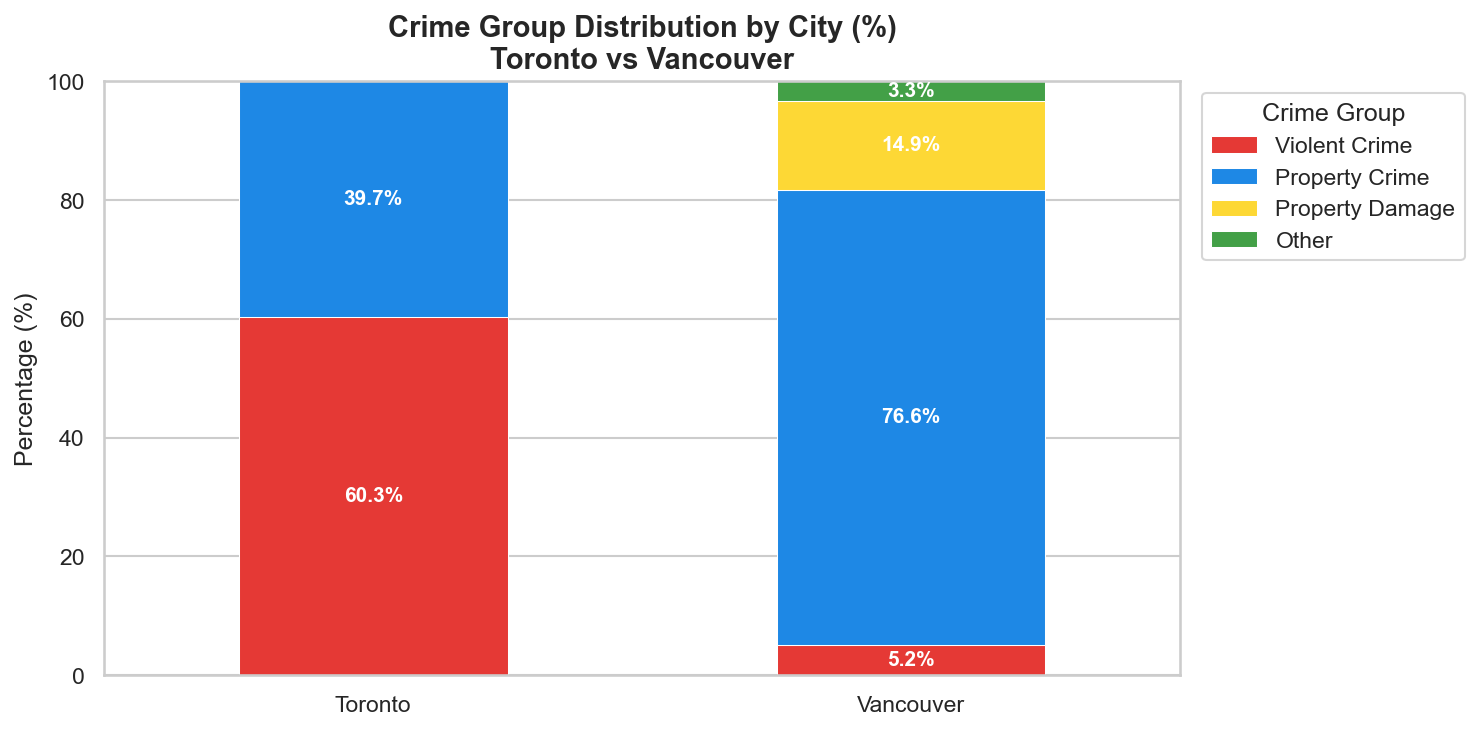

In [22]:
# Chart 2: Crime Type Distribution (stacked bar chart)
group_pct = (
    df.groupby(['city', 'crime_group'])
    .size()
    .reset_index(name='count')
)
group_pct['pct'] = group_pct.groupby('city')['count'].transform(lambda x: x / x.sum() * 100)

pivot = group_pct.pivot(index='city', columns='crime_group', values='pct').fillna(0)

col_order = ['Violent Crime', 'Property Crime', 'Property Damage','Other']
col_order = [c for c in col_order if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', stacked=True, ax=ax, color = ['#E53935', '#1e88E5', '#FDD835', '#43A047'], edgecolor='white', linewidth=0.5)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 1 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type='center', fontsize=10, color='white', weight='bold')


ax.set_title("Crime Group Distribution by City (%)\nToronto vs Vancouver", fontsize=14, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Crime Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../output/figures/crime_group_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


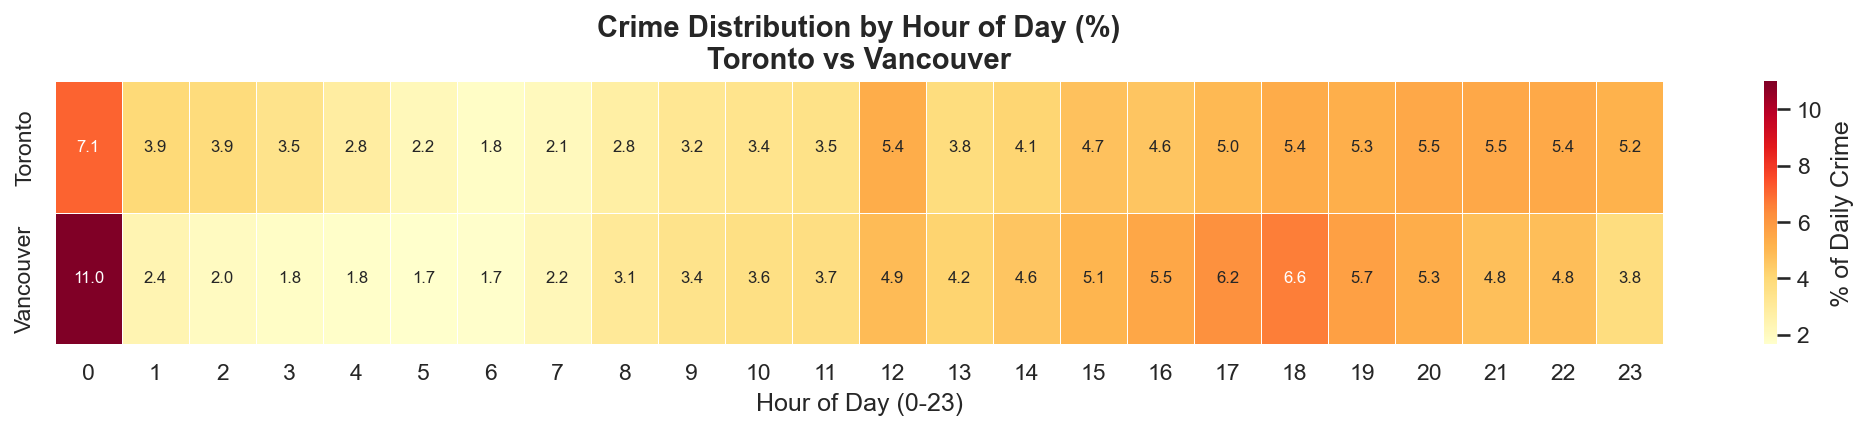

In [23]:
# Chart 3: Hourly Crime Patterns (heatmap)
hourly = (
    df.groupby(['city', 'hour'])
    .size()
    .reset_index(name='count')
)

# Normalize by total crimes per city
hourly['pct'] = hourly.groupby('city')['count'].transform(lambda x: x / x.sum() * 100)

pivot = hourly.pivot(index='city', columns='hour', values='pct')

fig,ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt=".1f", annot_kws={"size": 8}, linewidths=0.3, cbar_kws={'label': '% of Daily Crime'})

ax.set_title("Crime Distribution by Hour of Day (%)\nToronto vs Vancouver", fontsize=14, fontweight='bold')
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../output/figures/hourly_crime_patterns.png", dpi=150, bbox_inches='tight')
plt.show()

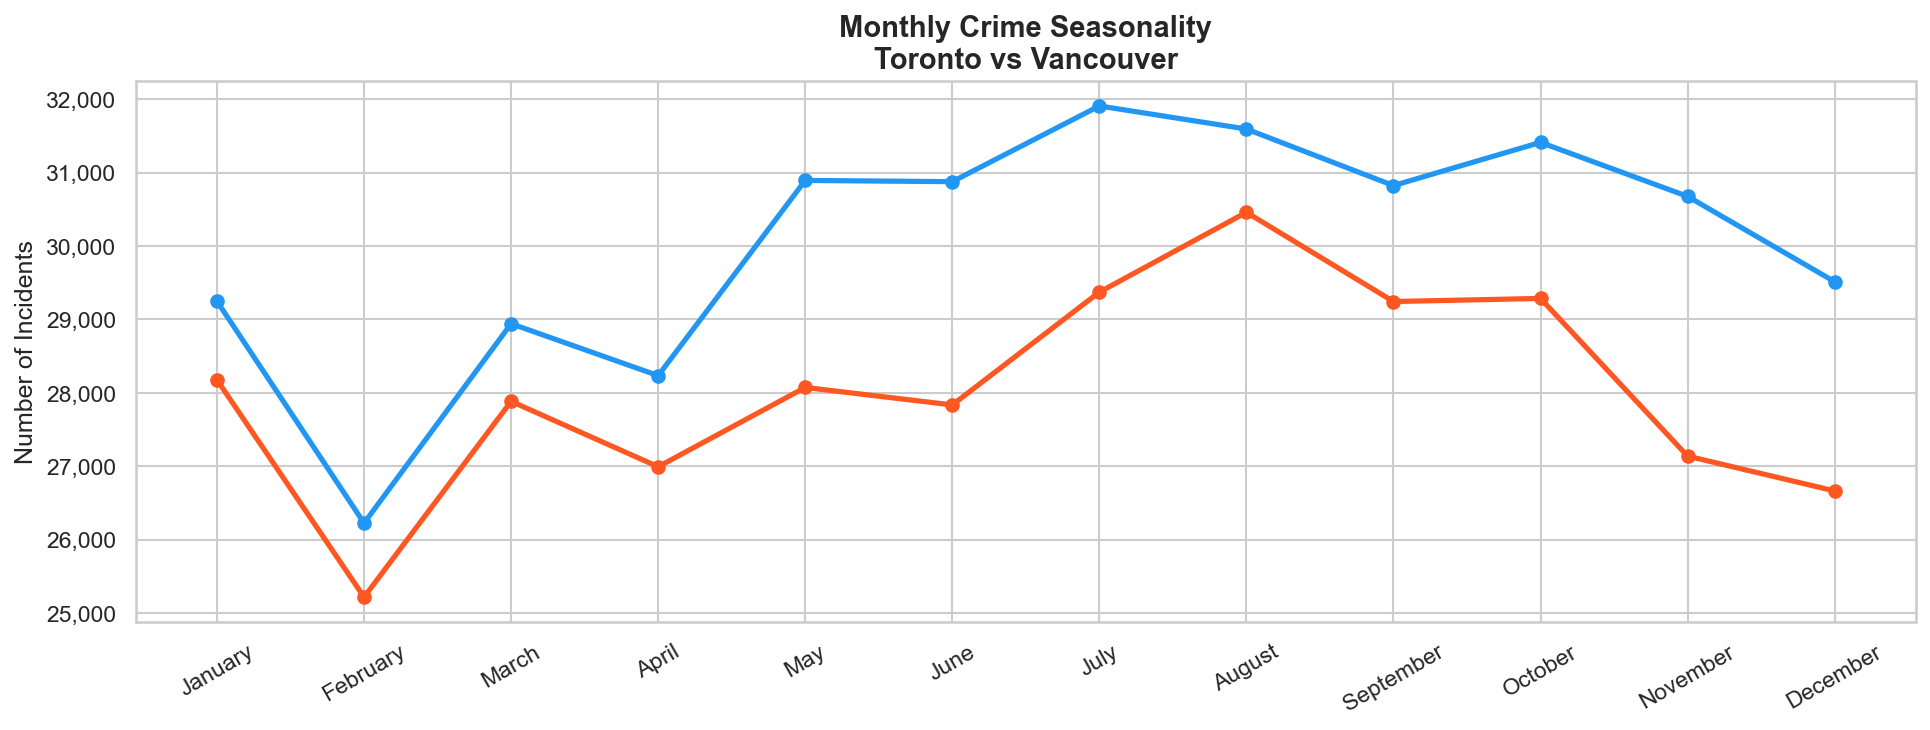

In [24]:
# Chart 4: Monthly Seansonality
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = (
    df.groupby(['city', 'month'])
    .size()
    .reset_index(name='count')
)
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(13, 5))
for city, grp in monthly.groupby('city'):
    ax.plot(grp['month'].astype(str), grp['count'], marker='o', label=city, color=COLORS[city], linewidth=2.5)
    
ax.set_title("Monthly Crime Seasonality\nToronto vs Vancouver", fontsize=14, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Number of Incidents")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=30)
ax.get_fc
plt.tight_layout()
plt.savefig("../output/figures/monthly_seasonality.png", dpi=150, bbox_inches='tight')
plt.show()

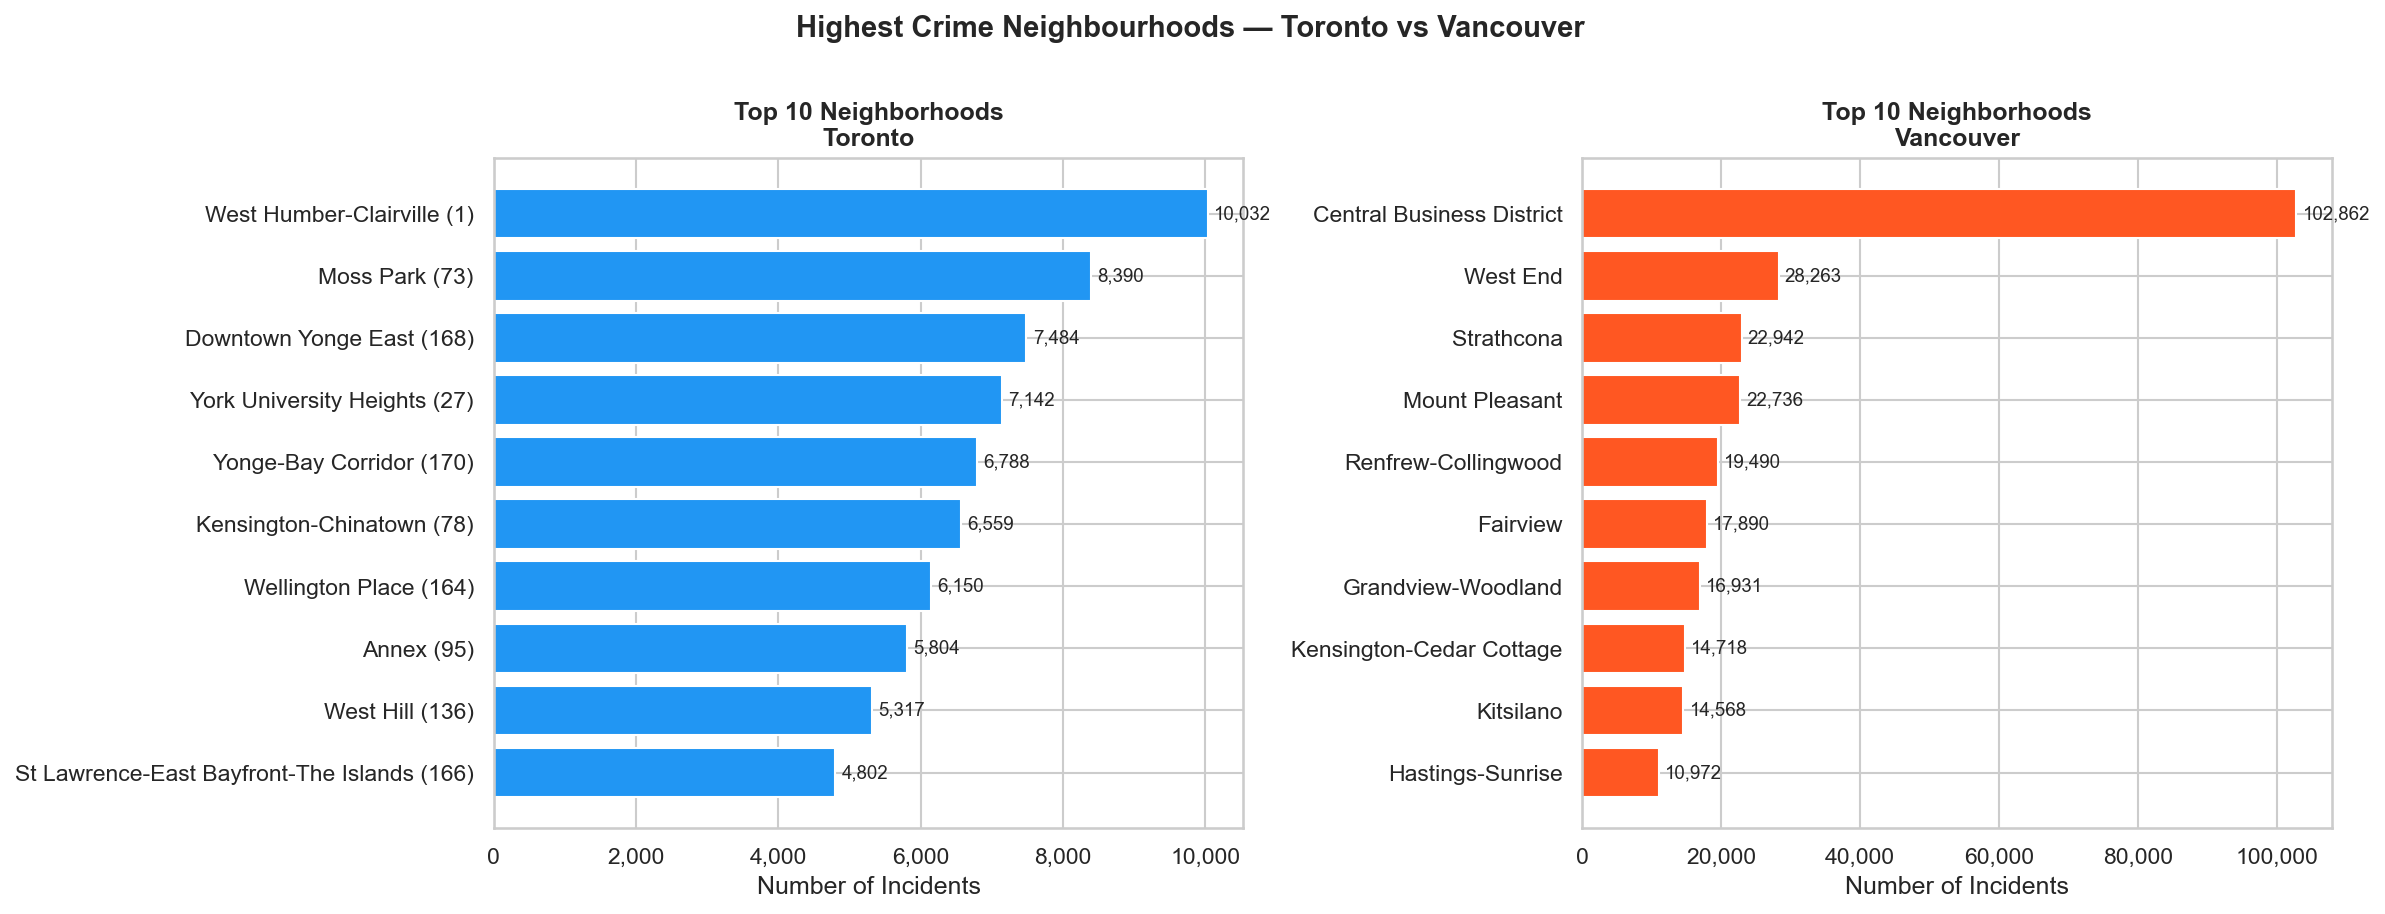

In [25]:
# Chart 5: Top 10 Neighborhoods
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, ['Toronto', 'Vancouver']):
    top10 = (
        df[df['city'] == city]
        .groupby('neighbourhood')
        .size()
        .nlargest(10)
        .reset_index(name='count')
        .sort_values('count')
    )
    bars = ax.barh(top10['neighbourhood'], top10['count'], color=COLORS[city], edgecolor='white')

    ax.bar_label(bars, fmt = '{:,.0f}', padding=3, fontsize=9)
    ax.set_title(f"Top 10 Neighborhoods\n{city}", fontweight='bold')
    ax.set_xlabel("Number of Incidents")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle("Highest Crime Neighbourhoods — Toronto vs Vancouver",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("../output/figures/top_neighbourhoods.png", dpi=150, bbox_inches='tight')
plt.show()


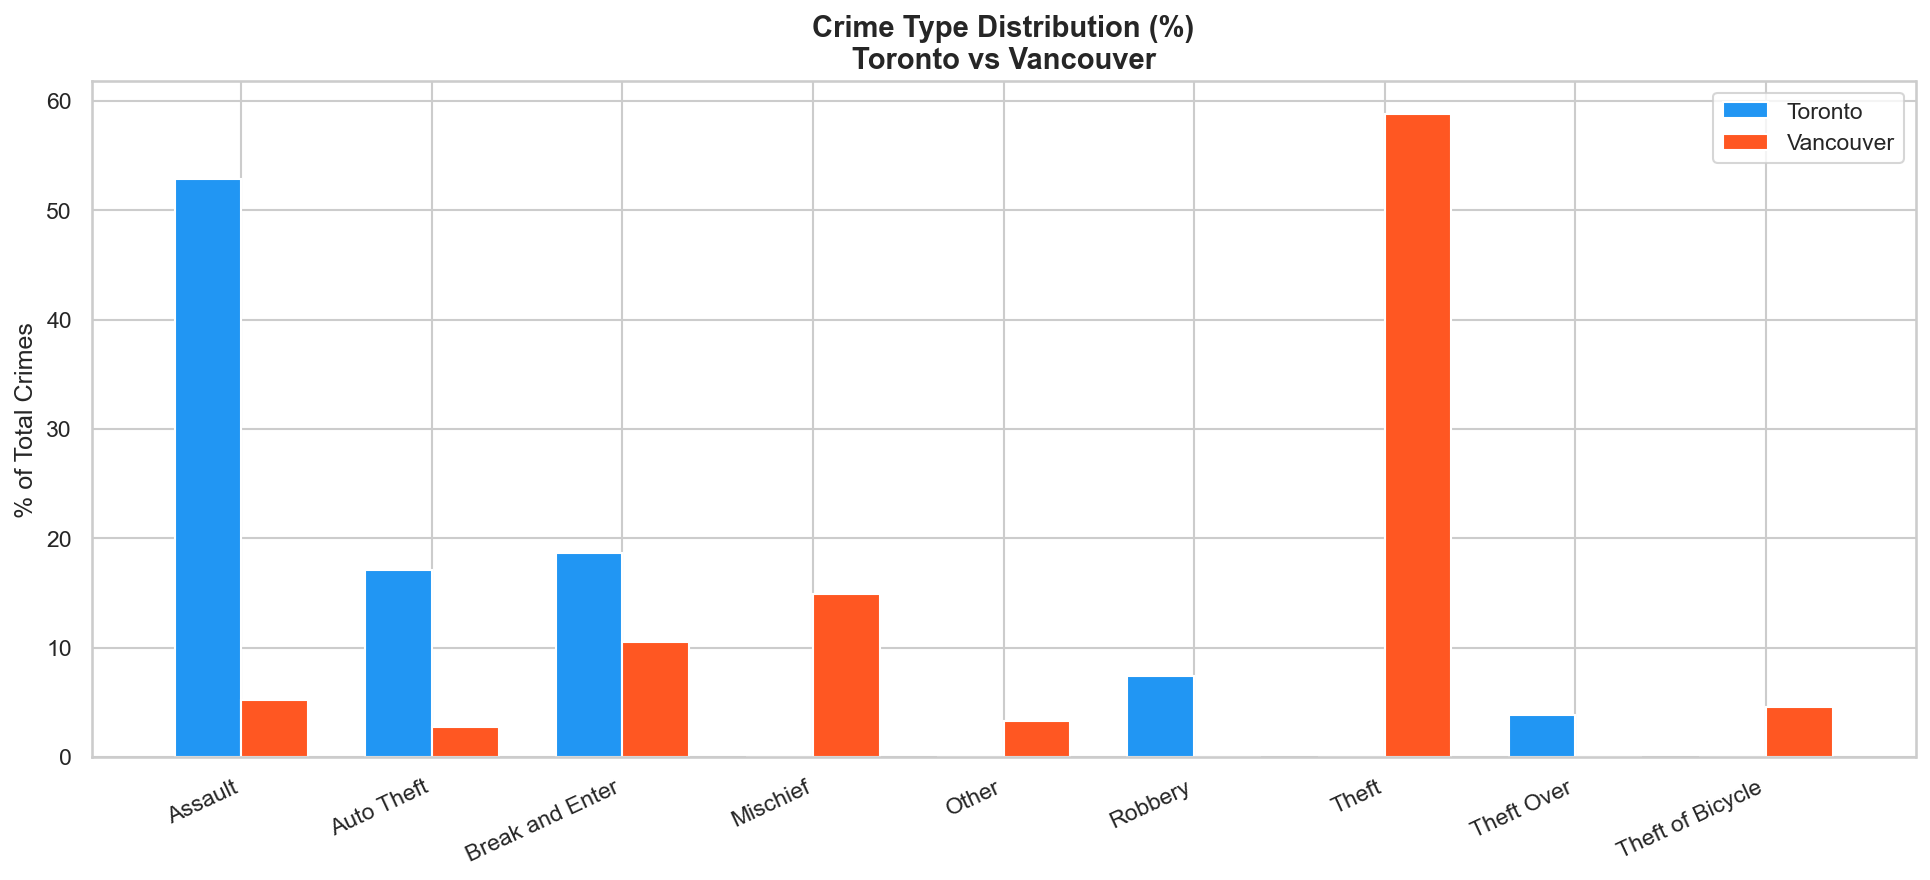

In [26]:
# Chart 6: Crime Type Comparison (side-by-side)
crime_counts = (
    df.groupby(['city', 'crime_type'])
    .size()
    .reset_index(name='count')
)

# Normalize by total crimes per city
crime_counts['pct'] = crime_counts.groupby('city')['count'].transform(lambda x: x / x.sum() * 100)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(crime_counts['crime_type'].nunique())
crime_types = crime_counts['crime_type'].unique()

width = 0.35
tor = crime_counts[crime_counts['city'] == 'Toronto'].set_index('crime_type')['pct']
van = crime_counts[crime_counts['city'] == 'Vancouver'].set_index('crime_type')['pct']

all_types = sorted(set(tor.index) | set(van.index))
tor_vals = [tor.get(ct, 0) for ct in all_types]
van_vals = [van.get(ct, 0) for ct in all_types]

x = range(len(all_types))
ax.bar([i - width/2 for i in x], tor_vals, width, label='Toronto', color=COLORS['Toronto'], edgecolor='white')
ax.bar([i + width/2 for i in x], van_vals, width, label='Vancouver', color=COLORS['Vancouver'], edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(all_types, rotation=25, ha='right')
ax.set_title("Crime Type Distribution (%)\nToronto vs Vancouver", fontsize=14, fontweight='bold')
ax.set_ylabel("% of Total Crimes")
ax.legend()
plt.tight_layout()
plt.savefig("../output/figures/crime_type_comparison.png", dpi=150, bbox_inches='tight')
plt.show()